In [1]:
a=1
a

1

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)

# Load Dataset

In [3]:
df = pd.read_csv('../data/spotify_tracks.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (114000, 21)

Columns:
 ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Basic Info

In [4]:
print("=== DTYPES ===")
print(df.dtypes)

print("\n=== DESCRIBE ===")
df.describe()

=== DTYPES ===
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== DESCRIBE ===


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


# Missing Values

Missing values:
 artists       1
album_name    1
track_name    1
dtype: int64


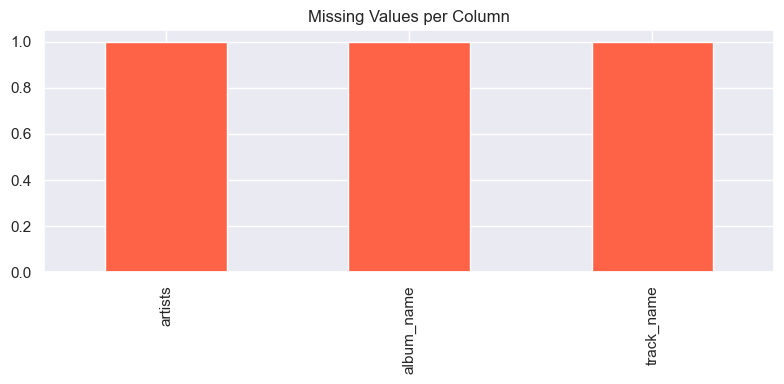

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values:\n", missing)

# Visual
if len(missing) > 0:
    missing.plot(kind='bar', color='tomato', figsize=(8, 4), title='Missing Values per Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values!")

# Audio Features Distribution

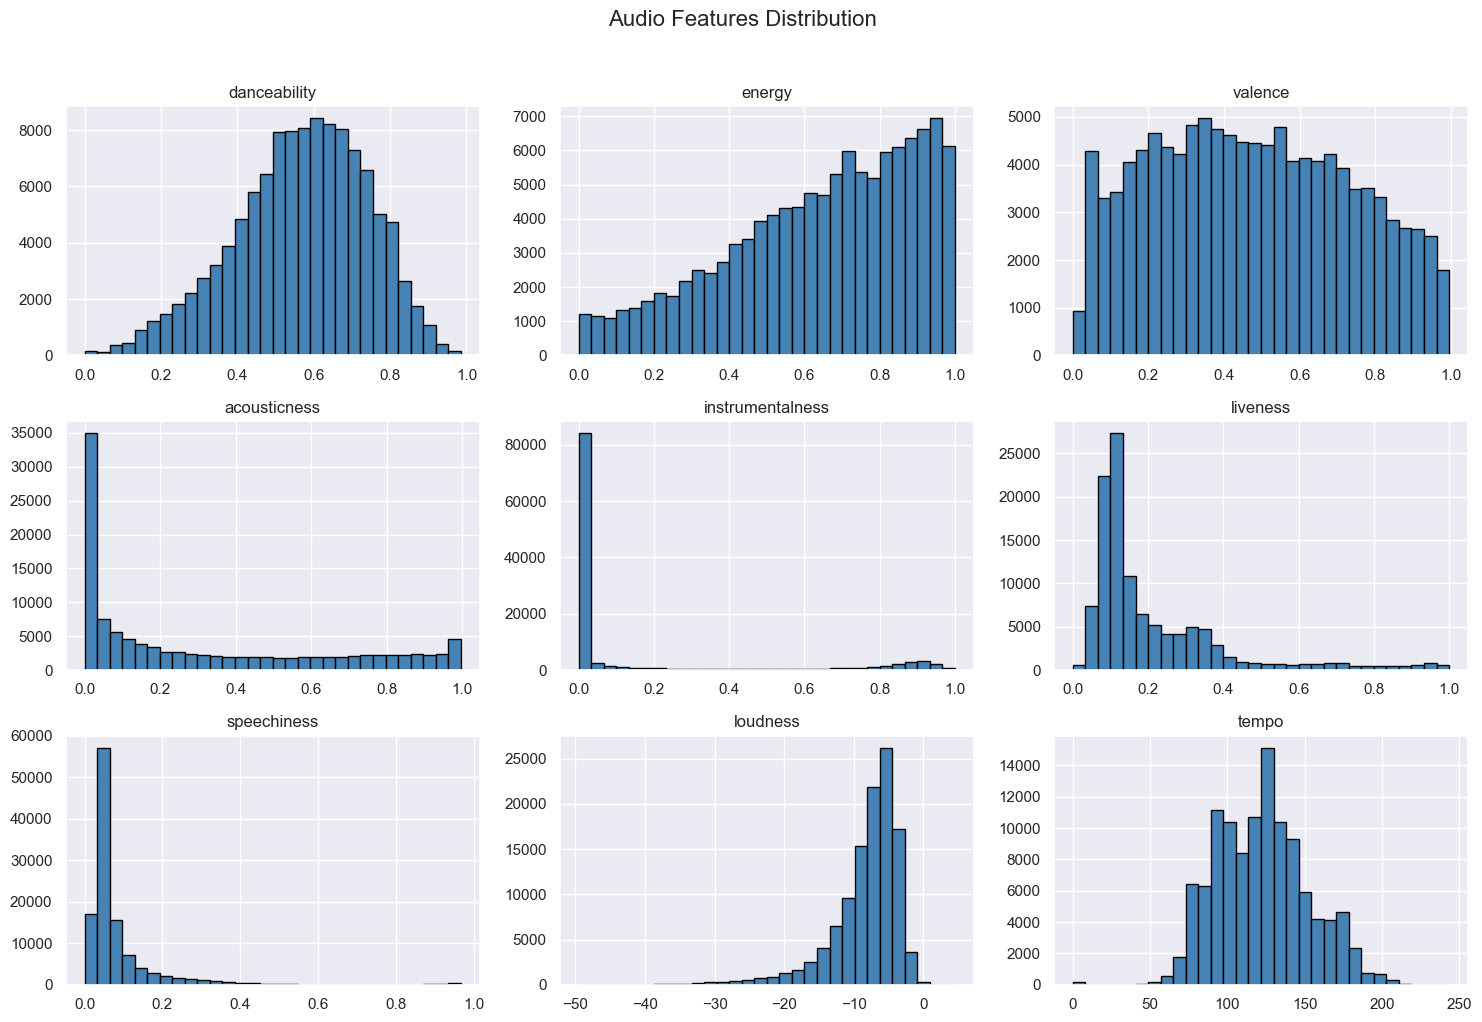

In [6]:
audio_features = [
    'danceability', 'energy', 'valence',
    'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'loudness', 'tempo'
]

df[audio_features].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Audio Features Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#  Correlation Heatmap

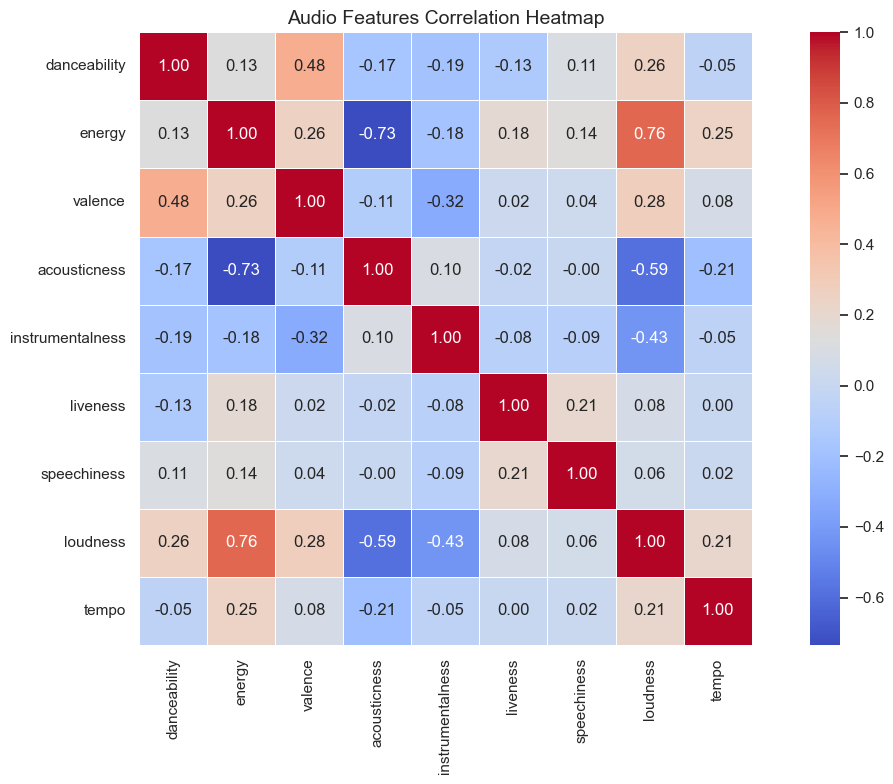

In [7]:
plt.figure(figsize=(12, 8))
corr = df[audio_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Audio Features Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top 20 Genres

C:\Users\jaisi\AppData\Local\Temp\ipykernel_5088\115706897.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


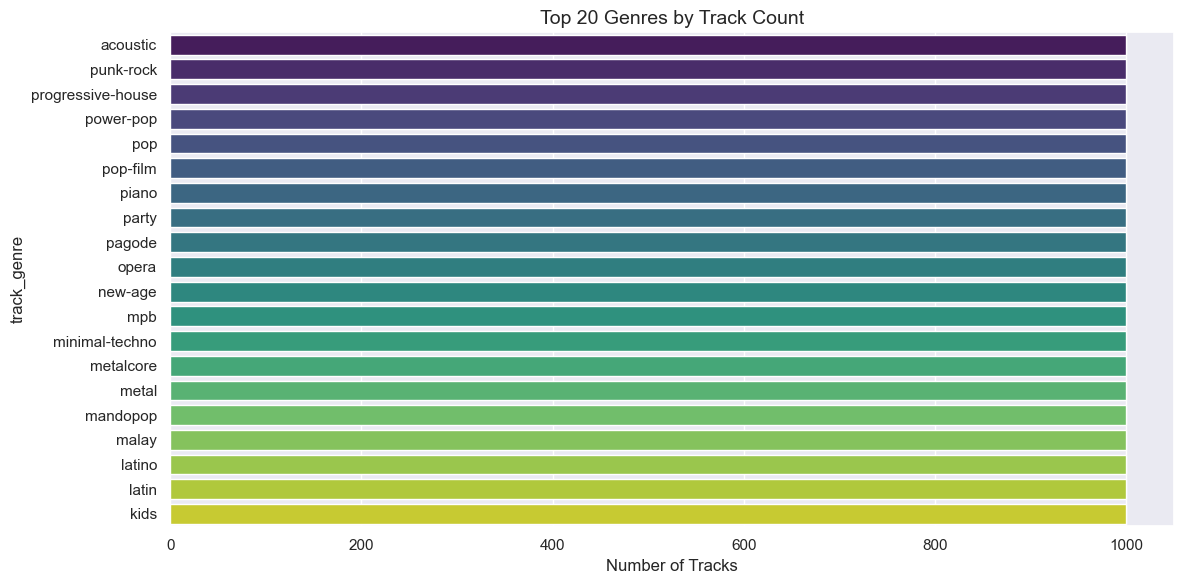

In [8]:
# Column name check kar lena — 'track_genre' ya 'genre' ho sakta hai
genre_col = 'track_genre'  # agar alag ho toh change karna

top_genres = df[genre_col].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 20 Genres by Track Count', fontsize=14)
plt.xlabel('Number of Tracks')
plt.tight_layout()
plt.show()

# Popularity Distribution

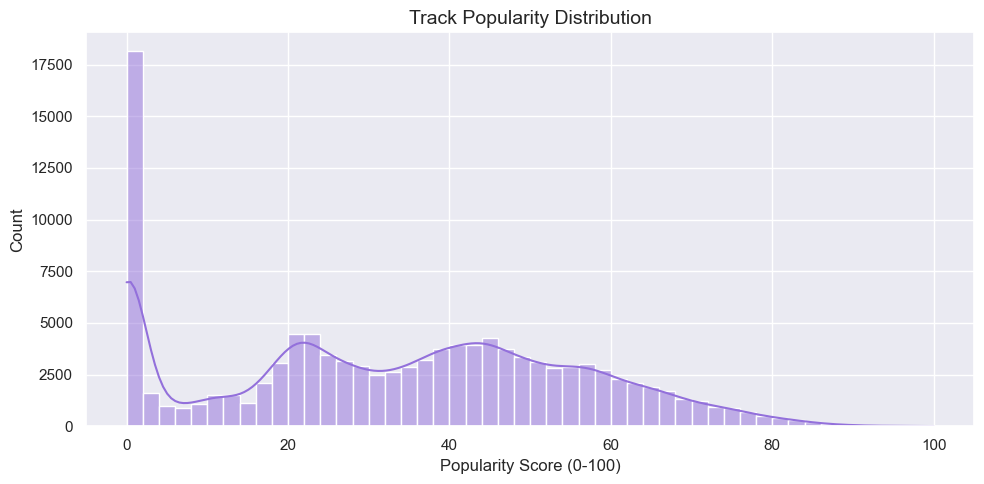

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='mediumpurple')
plt.title('Track Popularity Distribution', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')